In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [7]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [8]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_original_151617.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/daily


Launched SVR

In [9]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [10]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [11]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 99.32509660315299
R2 -> -0.024242718979705424
MAPE -> 0.13808288847820996


{'d2_absolute_error_score': -0.001465689122543301,
 'd2_pinball_score': -0.001465689122543301,
 'd2_tweedie_score': -0.024242718979705424,
 'explained_variance_score': -0.0011785505547303732,
 'max_error': 408.6909870957355,
 'mean_absolute_error': 69.87977821274232,
 'mean_absolute_percentage_error': 0.13808288847820996,
 'mean_gamma_deviance': 0.03155540258264833,
 'mean_poisson_deviance': 17.388791538006597,
 'mean_squared_error': 9865.474815225673,
 'mean_squared_log_error': 0.03640782826473504,
 'median_absolute_error': 45.466546900736375,
 'r2_score': -0.024242718979705424,
 'root_mean_squared_error': 99.32509660315299,
 'root_mean_squared_log_error': 0.1908083548085226}

Plots:

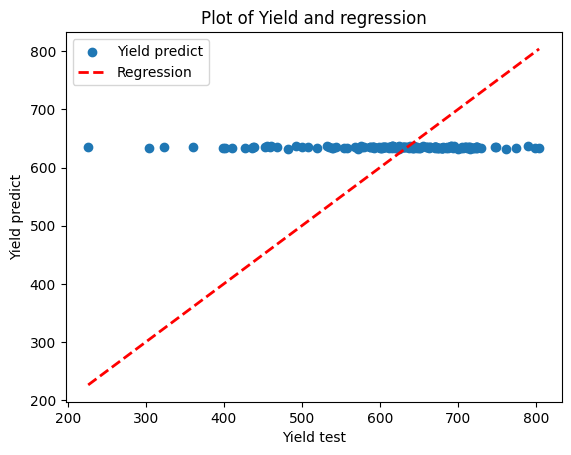

In [12]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [13]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [14]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118,
  'predict': 634.8027870957355,
  'error': 1.8074730602106373},
 {'truth': 304.5419,
  'predict': 634.3130413339791,
  'error': 1.0828432518940057},
 {'truth': 322.9881,
  'predict': 635.4849024861708,
  'error': 0.9675180060385222},
 {'truth': 360.0, 'predict': 635.3254071033928, 'error': 0.7647927975094243},
 {'truth': 398.2896, 'predict': 634.1837371147005, 'error': 0.592267880242669},
 {'truth': 400.8056, 'predict': 633.947255107504, 'error': 0.5816826289540465},
 {'truth': 409.865, 'predict': 634.3504781289314, 'error': 0.5477058985981516},
 {'truth': 427.0, 'predict': 634.2691541287566, 'error': 0.48540785510247436},
 {'truth': 436.0, 'predict': 633.5715866547499, 'error': 0.4531458409512613},
 {'truth': 437.0, 'predict': 634.9167578401458, 'error': 0.4528987593596014},
 {'truth': 438.9351,
  'predict': 634.8402362063848,
  'error': 0.4463191396777903},
 {'truth': 453.0, 'predict': 635.1200371752606, 'error': 0.40203098714185553},
 {'truth': 455.805,
  'predi